### Importing Pandas

In [3]:
import pandas as pd

## Stage 1 : Data Ingestion using pandas

In [4]:

df_deliveries = pd.read_csv("deliveries.csv")
df_matches = pd.read_csv("matches.csv")

In [5]:
print("Deliveries : \n",df_deliveries.head()) # deliveries.csv
print("\n\nMatches : \n",df_matches.head()) # matches.csv

Deliveries : 
    match_id  inning           batting_team                 bowling_team  over  \
0    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
1    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
2    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
3    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   
4    335982       1  Kolkata Knight Riders  Royal Challengers Bangalore     0   

   ball       batter   bowler  non_striker  batsman_runs  extra_runs  \
0     1   SC Ganguly  P Kumar  BB McCullum             0           1   
1     2  BB McCullum  P Kumar   SC Ganguly             0           0   
2     3  BB McCullum  P Kumar   SC Ganguly             0           1   
3     4  BB McCullum  P Kumar   SC Ganguly             0           0   
4     5  BB McCullum  P Kumar   SC Ganguly             0           0   

   total_runs extras_type  is_wicket player_dismissed dismissal_k

In [6]:
# shapes
print("Deliveries shape : ",df_deliveries.shape)
print("Matches shape : ", df_matches.shape)

# columns
print("\nDeliveries columns : \n",df_deliveries.columns)
print("\n")
print("Matches columns :\n",df_matches.columns)

# data types
print("\n Deliveries data types : ",df_deliveries.dtypes)
print("\nMatches data types : ",df_matches.dtypes)

Deliveries shape :  (260920, 17)
Matches shape :  (1095, 20)

Deliveries columns : 
 Index(['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball',
       'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs',
       'total_runs', 'extras_type', 'is_wicket', 'player_dismissed',
       'dismissal_kind', 'fielder'],
      dtype='str')


Matches columns :
 Index(['id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')

 Deliveries data types :  match_id            int64
inning              int64
batting_team          str
bowling_team          str
over                int64
ball                int64
batter                str
bowler                str
non_striker           str
batsman_runs        int64
extra_runs          int64
total_runs          i

## Stage 2 : Data Cleaning & Validation 

In [7]:
# checking number of null values in both files

df_deliveries.isnull().sum()
# df_matches.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [8]:
# handling null values in deliveries.csv

#changing the NA values in player_dismissed, dismissal_kind, fielder to 'none'
df_deliveries = df_deliveries.fillna('none')

In [9]:
# Removing inconsitency from deliveries.csv

# checking unique values foir inconsistency
df_deliveries['batting_team'].unique()
df_deliveries['bowling_team'].unique()

<StringArray>
['Royal Challengers Bangalore',       'Kolkata Knight Riders',
             'Kings XI Punjab',         'Chennai Super Kings',
            'Delhi Daredevils',            'Rajasthan Royals',
              'Mumbai Indians',             'Deccan Chargers',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',     'Rising Pune Supergiants',
               'Gujarat Lions',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
              'Gujarat Titans',        'Lucknow Super Giants',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str

In [10]:

# setting the correct batting team name
df_deliveries['batting_team'] = df_deliveries['batting_team'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})

# setting the correct bowling team name
df_deliveries['bowling_team'] = df_deliveries['bowling_team'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})

# checking if total runs are valid
df_deliveries[df_deliveries['total_runs'] != df_deliveries['batsman_runs'] + df_deliveries['extra_runs']]


,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder


In [11]:
# handling null values in matches.csv

# null cities
stadium_to_city = {
    'Dubai International Cricket Stadium': 'Dubai',
    'Sharjah Cricket Stadium': 'Sharjah'
}
 
df_matches['city'] = df_matches['city'].fillna(df_matches['venue'].map(stadium_to_city))


# null values in winner and player_of_match 
df_matches['winner'] = df_matches['winner'].fillna('no_result')
df_matches['player_of_match'] = df_matches['player_of_match'].fillna('none')

# null values in result_margin : changing to 0 (tie or abandoned match)
df_matches['result_margin'] = df_matches['result_margin'].fillna(0)

#  null values in method column : NA changes to 'normal'
df_matches['method'] = df_matches['method'].fillna('normal')

#

In [12]:
print(df_matches['team1'].unique())

<StringArray>
['Royal Challengers Bangalore',             'Kings XI Punjab',
            'Delhi Daredevils',              'Mumbai Indians',
       'Kolkata Knight Riders',            'Rajasthan Royals',
             'Deccan Chargers',         'Chennai Super Kings',
        'Kochi Tuskers Kerala',               'Pune Warriors',
         'Sunrisers Hyderabad',               'Gujarat Lions',
     'Rising Pune Supergiants',      'Rising Pune Supergiant',
              'Delhi Capitals',                'Punjab Kings',
        'Lucknow Super Giants',              'Gujarat Titans',
 'Royal Challengers Bengaluru']
Length: 19, dtype: str


In [13]:
# Removing inconsitency in matches.csv

# setting the correct team1 name
df_matches['team1'] = df_matches['team1'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})

# setting the correct team2 name
df_matches['team2'] = df_matches['team2'].replace({
    'Royal Challengers Bengaluru': 'Royal Challengers Bangalore',
    'Rising Pune Supergiant' : 'Rising Pune Supergiants',
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings'
})



In [14]:
# Validating ids

# Check if all delivery match_ids exist in matches
invalid_ids = df_deliveries[~df_deliveries['match_id'].isin(df_matches['id'])]
len(invalid_ids)

print(invalid_ids.head())

Empty DataFrame
Columns: [match_id, inning, batting_team, bowling_team, over, ball, batter, bowler, non_striker, batsman_runs, extra_runs, total_runs, extras_type, is_wicket, player_dismissed, dismissal_kind, fielder]
Index: []


In [15]:
# correct data types (numeric vs categorical)
df_deliveries.info()
print('\n\n')
df_matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   match_id          260920 non-null  int64
 1   inning            260920 non-null  int64
 2   batting_team      260920 non-null  str  
 3   bowling_team      260920 non-null  str  
 4   over              260920 non-null  int64
 5   ball              260920 non-null  int64
 6   batter            260920 non-null  str  
 7   bowler            260920 non-null  str  
 8   non_striker       260920 non-null  str  
 9   batsman_runs      260920 non-null  int64
 10  extra_runs        260920 non-null  int64
 11  total_runs        260920 non-null  int64
 12  extras_type       260920 non-null  str  
 13  is_wicket         260920 non-null  int64
 14  player_dismissed  260920 non-null  str  
 15  dismissal_kind    260920 non-null  str  
 16  fielder           260920 non-null  str  
dtypes: int64(8), str(9)
m

## Stage 3: Data Transformation

In [16]:
# Prepare data for analysis.

#Create new columns:

# total runs scored
df_deliveries['total_runs_calculated'] = df_deliveries['batsman_runs'] + df_deliveries['extra_runs']

# runs from batsman
df_deliveries['pure_batting_runs'] = df_deliveries['batsman_runs']

# total balls
df_deliveries['ball_number'] = df_deliveries['over'] * 6 + df_deliveries['ball']


print(df_deliveries['total_runs_calculated'].head())
print(df_deliveries['pure_batting_runs'].head())
print(df_deliveries['ball_number'].head())



0    1
1    0
2    1
3    0
4    0
Name: total_runs_calculated, dtype: int64
0    0
1    0
2    0
3    0
4    0
Name: pure_batting_runs, dtype: int64
0    1
1    2
2    3
3    4
4    5
Name: ball_number, dtype: int64


In [17]:
# Standardize columns

# changing column names to match
df_matches.rename(columns={'id': 'match_id'}, inplace=True)

# for avoiding confusion
df_deliveries.columns = df_deliveries.columns.str.lower()
df_matches.columns = df_matches.columns.str.lower()

print(df_matches.columns)

Index(['match_id', 'season', 'city', 'date', 'match_type', 'player_of_match',
       'venue', 'team1', 'team2', 'toss_winner', 'toss_decision', 'winner',
       'result', 'result_margin', 'target_runs', 'target_overs', 'super_over',
       'method', 'umpire1', 'umpire2'],
      dtype='str')


In [18]:
# merge
df_final = df_deliveries.merge(
    df_matches,
    on='match_id',
    how='left'
)

print(df_deliveries.shape)
print(df_matches.shape)
print(df_final.shape)

(260920, 20)
(1095, 20)
(260920, 39)


In [19]:
df_final

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,...,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,...,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,normal,Asad Rauf,RE Koertzen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
260915,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,5,SS Iyer,AK Markram,VR Iyer,1,...,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,normal,J Madanagopal,Nitin Menon
260916,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,9,6,VR Iyer,AK Markram,SS Iyer,1,...,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,normal,J Madanagopal,Nitin Menon
260917,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,1,VR Iyer,Shahbaz Ahmed,SS Iyer,1,...,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,normal,J Madanagopal,Nitin Menon
260918,1426312,2,Kolkata Knight Riders,Sunrisers Hyderabad,10,2,SS Iyer,Shahbaz Ahmed,VR Iyer,1,...,bat,Kolkata Knight Riders,wickets,8.0,114.0,20.0,N,normal,J Madanagopal,Nitin Menon


## Core Analysis


In [20]:
#  Total runs per match

runs_per_match = df_final.groupby('match_id')['total_runs'].sum()
runs_per_match = runs_per_match.reset_index() # converting to dataframe
print(runs_per_match)

      match_id  total_runs
0       335982         304
1       335983         447
2       335984         261
3       335985         331
4       335986         222
...        ...         ...
1090   1426307         429
1091   1426309         323
1092   1426310         346
1093   1426311         314
1094   1426312         227

[1095 rows x 2 columns]


In [21]:
# 2. Runs per Team per Match

runs_per_team_per_match = df_final.groupby(['match_id','batting_team'])['total_runs'].sum().reset_index()
print(runs_per_team_per_match)

      match_id                 batting_team  total_runs
0       335982        Kolkata Knight Riders         222
1       335982  Royal Challengers Bangalore          82
2       335983          Chennai Super Kings         240
3       335983                 Punjab Kings         207
4       335984               Delhi Capitals         132
...        ...                          ...         ...
2182   1426310  Royal Challengers Bangalore         172
2183   1426311             Rajasthan Royals         139
2184   1426311          Sunrisers Hyderabad         175
2185   1426312        Kolkata Knight Riders         114
2186   1426312          Sunrisers Hyderabad         113

[2187 rows x 3 columns]


In [58]:
# 3. Top 10 Batters

top_batters = df_final.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).reset_index(name='total_runs')

print(top_batters)

           batter  total_runs
0         V Kohli        8014
1        S Dhawan        6769
2       RG Sharma        6630
3       DA Warner        6567
4        SK Raina        5536
5        MS Dhoni        5243
6  AB de Villiers        5181
7        CH Gayle        4997
8      RV Uthappa        4954
9      KD Karthik        4843


In [23]:
# 4. Strike Rate of Batters

# except no ball, all other deliveires are not counted in the balls faced by the batsman

# valid balls 
valid_balls = df_final[
    ~df_final['extras_type'].isin(['wides', 'byes', 'legbyes', 'penalty'])
]

# runs per batter
runs = df_final.groupby('batter')['batsman_runs'].sum()

# balls faced per batter
balls = valid_balls.groupby('batter').size()

# strike rate
strike_rate = (runs / balls) * 100

# convert to DataFrame
strike_rate = strike_rate.reset_index(name='strike_rate')

print(strike_rate.head())

           batter  strike_rate
0  A Ashish Reddy   146.596859
1        A Badoni   136.051502
2      A Chandila    57.142857
3        A Chopra    75.714286
4     A Choudhary   125.000000


In [24]:
# 5. Top 10 Bowlers by Economy

# valid balls
valid_balls = df_final[
    ~df_final['extras_type'].isin(['wide','noballs'])
]

# runs conceded by the bowler
runs = df_final.groupby('bowler')['total_runs'].sum()

# balls bowled
ball_bowled  =valid_balls.groupby('bowler').size()

overs = ball_bowled / 6 # overs

# economy
economy = runs / overs
economy = economy.reset_index(name='economy_rate')

# top bowlers
top_bowlers = economy.sort_values(by='economy_rate').head()

print(top_bowlers)


           bowler  economy_rate
24   AC Gilchrist          0.00
364    R Ravindra          3.50
317      NB Singh          4.32
460   Sachin Baby          4.80
38      AM Rahane          5.00


In [25]:
# 6. Most consistent batter

# runs per match
runs_per_match = df_final.groupby(['match_id','batter'])['batsman_runs'].sum().reset_index()

# avg runs
avg_runs = runs_per_match.groupby('batter')['batsman_runs'].mean()

# matches played
matches_played = runs_per_match.groupby('batter')['match_id'].nunique()

# consistency
consistency = pd.DataFrame({
    'average_runs':avg_runs,
    'matches_played' : matches_played
})

# applying filter
consistency = consistency[consistency['matches_played'] >= 30]

top_consistent = consistency.sort_values(
    by='average_runs',
    ascending=False
).head(10)

print(top_consistent.reset_index())

         batter  average_runs  matches_played
0      KL Rahul     38.434426             122
1    RD Gaikwad     36.615385              65
2      SE Marsh     36.072464              69
3     DA Warner     35.690217             184
4      CH Gayle     35.439716             141
5     ML Hayden     34.593750              32
6    MEK Hussey     34.086207              58
7    JC Buttler     33.801887             106
8  F du Plessis     33.123188             138
9       V Kohli     32.844262             244


In [26]:
# 7. Highest Individual Score in a Match

# runs per batter per match
batter_match_runs = df_final.groupby(
    ['batter', 'match_id']
)['batsman_runs'].sum().reset_index()

# highest score by batsman
highest_score = batter_match_runs.sort_values(
    by='batsman_runs',
    ascending=False
).head(1)

print(highest_score)

        batter  match_id  batsman_runs
2469  CH Gayle    598027           175


In [27]:
# 8. Boundary Analysis

# total number of 4's and 6's
fours = df_final[df_final['batsman_runs'] == 4].shape[0]
sixes = df_final[df_final['batsman_runs'] == 6].shape[0]

print("Total 4s:", fours)
print("Total 6s:", sixes)
print("Total boundaries: ",fours+sixes)


boundaries = df_final[
    df_final['batsman_runs'].isin([4, 6])
]

# count per batter
top_boundary_players = boundaries.groupby('batter').size()

# top batters
top_boundary_players = top_boundary_players.sort_values(ascending=False).head(10)

# convert to dataframe
top_boundary_players = top_boundary_players.reset_index(name='boundary_count')

print('\n\n',top_boundary_players)

Total 4s:

 29850
Total 6s: 13051
Total boundaries:  42901


            batter  boundary_count
0         V Kohli             981
1        S Dhawan             921
2       DA Warner             899
3       RG Sharma             880
4        CH Gayle             767
5        SK Raina             710
6  AB de Villiers             667
7      RV Uthappa             663
8      KD Karthik             627
9        MS Dhoni             615


In [28]:
# 9. Boundary Percentage

# get runs by boundary
boundary_runs = df_final[
    df_final['batsman_runs'].isin([4, 6])
].groupby('batter')['batsman_runs'].sum()

# boundary %
boundary_percentage = (boundary_runs / runs) * 100

# convert to dataframe
boundary_percentage = boundary_percentage.reset_index(name='boundary_percentage')

print(boundary_percentage)

             batter  boundary_percentage
0    A Ashish Reddy            38.500000
1          A Badoni           886.486486
2        A Chandila                  NaN
3          A Chopra                  NaN
4       A Choudhary             6.944444
..              ...                  ...
712     Yash Thakur                  NaN
713   Yashpal Singh                  NaN
714   Yudhvir Singh            12.800000
715    Yuvraj Singh           161.869844
716          Z Khan             1.958042

[717 rows x 2 columns]


In [29]:
# 10. Dot ball analysis

# total dot balls
dot_balls = df_final[df_final['total_runs'] == 0].shape[0]

print("Total dot balls:", dot_balls)

# balls by bowler
df_dot_balls = df_final[df_final['total_runs'] == 0]
bowler_dot_balls = df_dot_balls.groupby('bowler').size()

# top bowlers
top_dot_bowlers = bowler_dot_balls.sort_values(ascending=False).head(10)
top_dot_bowlers = top_dot_bowlers.reset_index(name='dot_balls')

print(top_dot_bowlers)

Total dot balls: 90438
            bowler  dot_balls
0          B Kumar       1632
1        SP Narine       1569
2         R Ashwin       1552
3        PP Chawla       1325
4  Harbhajan Singh       1263
5        JJ Bumrah       1228
6        RA Jadeja       1216
7        YS Chahal       1194
8         UT Yadav       1186
9         A Mishra       1185


In [30]:
# 11. Runs per Over Analysis

# runs per over per match
over_runs = df_final.groupby(
    ['match_id', 'over']
)['total_runs'].sum().reset_index()

# average runs
avg_runs_per_over = over_runs.groupby('over')['total_runs'].mean().reset_index()
avg_runs_per_over.rename(columns={'total_runs': 'avg_runs'}, inplace=True)

print(avg_runs_per_over)

high_scoring_overs = avg_runs_per_over.sort_values(
    by='avg_runs',
    ascending=False
).head(5)

print('\n\n',high_scoring_overs)

    over   avg_runs
0      0  12.466667
1      1  14.760731
2      2  16.342466
3      3  16.817352
4      4  16.954338
5      5  16.936015
6      6  13.563985
7      7  14.607861
8      8  15.223239
9      9  14.961574
10    10  15.379468
11    11  15.694853
12    12  15.842541
13    13  16.252535
14    14  16.727189
15    15  17.056325
16    16  17.669145
17    17  18.245336
18    18  17.979265
19    19  16.967526


     over   avg_runs
17    17  18.245336
18    18  17.979265
16    16  17.669145
15    15  17.056325
19    19  16.967526


In [31]:
# 12. Power play performance

powerplay = df_final[df_final['over'].between(1, 6)]

# total runs in powerplay
total_powerplay_runs = powerplay['total_runs'].sum()
print("Total powerplay runs:", total_powerplay_runs)

# runs by each teams
team_powerplay_runs = powerplay.groupby('batting_team')['total_runs'].sum()
team_powerplay_runs = team_powerplay_runs.reset_index(name='powerplay_runs')

# top performing teams
top_powerplay_teams = team_powerplay_runs.sort_values(
    by='powerplay_runs',
    ascending=False
).head(10)

print(top_powerplay_teams)

Total powerplay runs: 104405
                   batting_team  powerplay_runs
8                Mumbai Indians           12371
2                Delhi Capitals           12212
10                 Punjab Kings           11980
6         Kolkata Knight Riders           11912
13  Royal Challengers Bangalore           11798
0           Chennai Super Kings           11379
11             Rajasthan Royals           10333
14          Sunrisers Hyderabad            9047
1               Deccan Chargers            3407
4                Gujarat Titans            2216


In [32]:
#13. Death Overs Performance

death_over = df_final[df_final['over'].between(16, 20)]

# total runs in powerplay
total_death_over_runs = death_over['total_runs'].sum()
print("Total powerplay runs:", total_death_over_runs)

# runs by each teams
team_death_over_runs = death_over.groupby('batting_team')['total_runs'].sum()
team_death_over_runs = team_death_over_runs.reset_index(name='death_over_runs')

# top performing teams
top_death_over_teams = team_death_over_runs.sort_values(
    by='death_over_runs',
    ascending=False
).head(10)

print(top_death_over_teams)

Total powerplay runs: 75412
                   batting_team  death_over_runs
8                Mumbai Indians             9598
0           Chennai Super Kings             9061
13  Royal Challengers Bangalore             9028
10                 Punjab Kings             8274
2                Delhi Capitals             8184
6         Kolkata Knight Riders             8053
11             Rajasthan Royals             7281
14          Sunrisers Hyderabad             6237
1               Deccan Chargers             2539
4                Gujarat Titans             1823


In [33]:
# 14. Run Distribution per Inning

# not counting super over innings
normal_innings = df_final[df_final['inning'].isin([1, 2])]
runs_per_inning = normal_innings.groupby('inning')['total_runs'].sum().reset_index()

print(runs_per_inning)

   inning  total_runs
0       1      181274
1       2      166196


In [34]:
# 15. Toss Impact Analysis

# removing super overs
df = df_final[df_final['inning'].isin([1, 2])]

# teams run per match
team_match_runs = df.groupby(
    ['match_id', 'batting_team']
)['total_runs'].sum().reset_index()

# merginf toss details
team_match_runs = team_match_runs.merge(
    df_matches[['match_id', 'toss_winner']],
    on='match_id'
)

# identify toss winner vs opponent
team_match_runs['is_toss_winner'] = (
    team_match_runs['batting_team'] == team_match_runs['toss_winner']
)

toss_analysis = team_match_runs.groupby(
    'is_toss_winner'
)['total_runs'].mean().reset_index()

print(toss_analysis)

   is_toss_winner  total_runs
0           False  160.155538
1            True  157.102845


In [35]:
# 16. Player of Match Contribution

# runs per batter per match
batter_match_runs = df_final.groupby(
    ['match_id', 'batter']
)['batsman_runs'].sum().reset_index()

# highest scorer per match
top_scorers = batter_match_runs.loc[
    batter_match_runs.groupby('match_id')['batsman_runs'].idxmax()
]

# player of the match
pom = df_matches[['match_id', 'player_of_match']]

# comparison 
comparison = top_scorers.merge(pom, on='match_id')

# check if same player
comparison['is_same'] = (
    comparison['batter'] == comparison['player_of_match']
)

print(comparison['is_same'].value_counts())

is_same
False    599
True     496
Name: count, dtype: int64


In [36]:
# 17. Venue-wise Analysis

# removing inconsistency in the venue data, removing the city name after ','
df_final['venue'] = df_final['venue'].str.replace(',.*', '', regex=True)

# calculating matches per venue
matches_per_venue = df_final.groupby('venue')['match_id'].nunique().reset_index()
print(matches_per_venue.head())
print('\n\n')
# runs per venue
runs_per_venue = df_final.groupby(['venue','match_id'])['total_runs'].sum().reset_index()

# average runs at each venue
avg_runs_per_venue = runs_per_venue.groupby('venue')['total_runs'].mean().reset_index()
avg_runs_per_venue.rename(columns={'total_runs':'avg_runs'}, inplace=True)
print(avg_runs_per_venue.head())

                                               venue  match_id
0                               Arun Jaitley Stadium        30
1                                   Barabati Stadium         7
2                          Barsapara Cricket Stadium         3
3  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...        14
4                                  Brabourne Stadium        27



                                               venue    avg_runs
0                               Arun Jaitley Stadium  354.466667
1                                   Barabati Stadium  325.428571
2                          Barsapara Cricket Stadium  339.666667
3  Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...  306.714286
4                                  Brabourne Stadium  344.629630


In [37]:
# 18. City-wise Scoring Trends

# runs per city
runs_per_city = df_final.groupby(['city','match_id'])['total_runs'].sum().reset_index()

# average runs per city
avg_runs_per_city = runs_per_city.groupby('city')['total_runs'].mean().reset_index()
print(avg_runs_per_city.head())

top_scoring_cities = avg_runs_per_city.sort_values(by='total_runs',ascending=False)
print('\n\n',top_scoring_cities.head())

           city  total_runs
0     Abu Dhabi  306.270270
1     Ahmedabad  331.027778
2     Bangalore  311.738462
3     Bengaluru  360.310345
4  Bloemfontein  264.500000


           city  total_runs
3    Bengaluru  360.310345
15    Guwahati  339.666667
11  Dharamsala  339.384615
25      Mohali  335.000000
32      Rajkot  333.300000


In [38]:
# 19. Season-wise Run Trends

# runs per season
runs_per_season = df_final.groupby('season')['total_runs'].sum().reset_index()
print(runs_per_season.head())
print('\n\n')

# calculating difference in runs scored in consecutive seasons
runs_per_season['run_difference'] = runs_per_season['total_runs'].diff()
print(runs_per_season.head())

    season  total_runs
0  2007/08       17937
1     2009       16353
2  2009/10       18883
3     2011       21154
4     2012       22453



    season  total_runs  run_difference
0  2007/08       17937             NaN
1     2009       16353         -1584.0
2  2009/10       18883          2530.0
3     2011       21154          2271.0
4     2012       22453          1299.0


In [39]:
# 20. Winning Team Analysis

# removing super overs
df = df_final[df_final['inning'].isin([1, 2])]

# runs per team per inning per match
team_runs = df.groupby(['match_id', 'inning', 'batting_team'])['total_runs'].sum().reset_index()

# predicting winner
predicted_winner = team_runs.loc[team_runs.groupby('match_id')['total_runs'].idxmax()]

# actual winner
actual = df_matches[['match_id', 'winner']]

# comparing
comparison = predicted_winner.merge(actual, on='match_id')
comparison['correct_prediction'] = (
    comparison['batting_team'] == comparison['winner']
)

# result
comparison['correct_prediction'].value_counts()

# accuracy
accuracy = comparison['correct_prediction'].mean() * 100
print("Accuracy:", accuracy)

Accuracy: 82.55707762557077


## Stage 5 : Derived Insights

In [40]:
# Most Consistent batter
print('Most Consistent batter\n',top_consistent.head(1)) 
print('\n')

# Best death-over team
print('Best death-over team\n',top_death_over_teams.head(1))
print('\n')

# High-scoring venues
runs_per_venue = runs_per_venue.sort_values(by='total_runs',ascending=False)
print('High-scoring venues\n',runs_per_venue.head(1))

Most Consistent batter
           average_runs  matches_played
batter                                
KL Rahul     38.434426             122


Best death-over team
      batting_team  death_over_runs
8  Mumbai Indians             9598


High-scoring venues
                      venue  match_id  total_runs
461  M Chinnaswamy Stadium   1426268         549


## Stage 6 : Reporting

In [41]:
# already used snake_case for every column name and sorted every dataframe in previous stages already

## Stage 7: Data Export

In [42]:
import os

os.makedirs("output", exist_ok=True)

# runs per match
runs_per_match.to_csv("output/runs_per_match.csv", index=False)

# top batters
top_batters.to_csv("output/top_batters.csv", index=False)

# strike rate
strike_rate.to_csv("output/strike_rate.csv", index=False)

# economy
economy.to_csv("output/economy.csv", index=False)

# team scores per match
runs_per_team_per_match.to_csv("output/team_scores.csv", index=False)

# death over
death_over.to_csv("output/death_overs.csv", index=False)


# Export to Excel
with pd.ExcelWriter("output/ipl_analysis.xlsx") as writer:
    runs_per_match.to_excel(writer, sheet_name="Runs per Match", index=False)
    top_batters.to_excel(writer, sheet_name="Top Batters", index=False)
    strike_rate.to_excel(writer, sheet_name="Strike Rate", index=False)
    economy.to_excel(writer, sheet_name="Economy", index=False)
    runs_per_team_per_match.to_excel(writer, sheet_name="Team Scores", index=False)
    death_over.to_excel(writer, sheet_name="Death Overs", index=False)

## Data Visualization

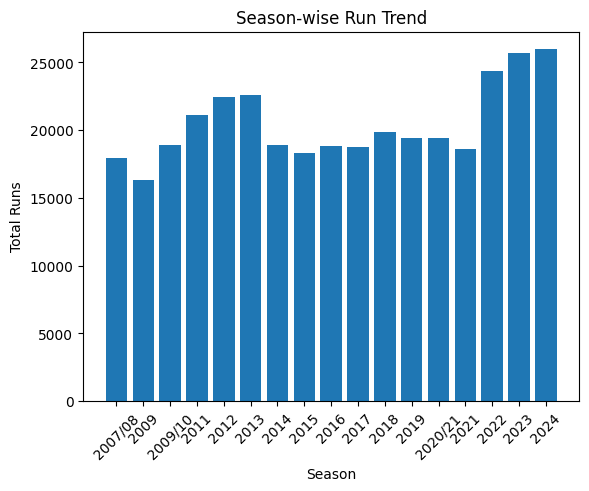

In [52]:
import matplotlib.pyplot as plt

# bar chart for runs per season
plt.bar(runs_per_season['season'], runs_per_season['total_runs'])
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.title("Season-wise Run Trend")
plt.xticks(rotation=45)
plt.show()

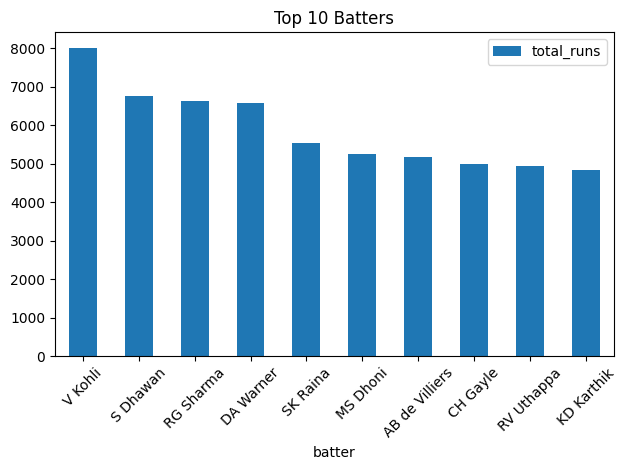

In [ ]:
# top 10 batters
top_batters.head(10).plot(
    kind='bar',
    x='batter',
    y='total_runs'
)

plt.title("Top 10 Batters")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

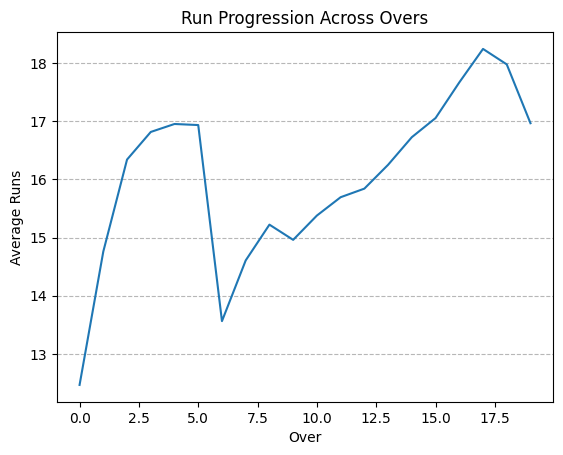

In [69]:
# average runs per over
plt.plot(avg_runs_per_over['over'], avg_runs_per_over['avg_runs'])
plt.title("Run Progression Across Overs")
plt.xlabel("Over")
plt.ylabel("Average Runs")
plt.grid(axis='y', linestyle='--', alpha=0.9)
plt.show()

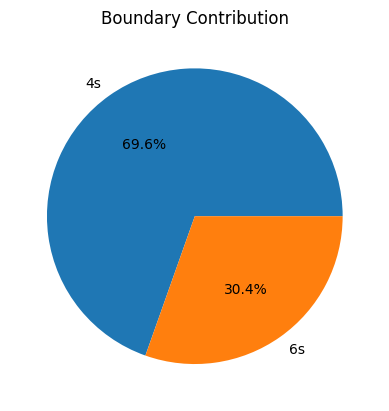

In [ ]:
# boundary contribution
plt.pie([fours, sixes], labels=['4s', '6s'], autopct='%1.1f%%')
plt.title("Boundary Contribution")
plt.show()

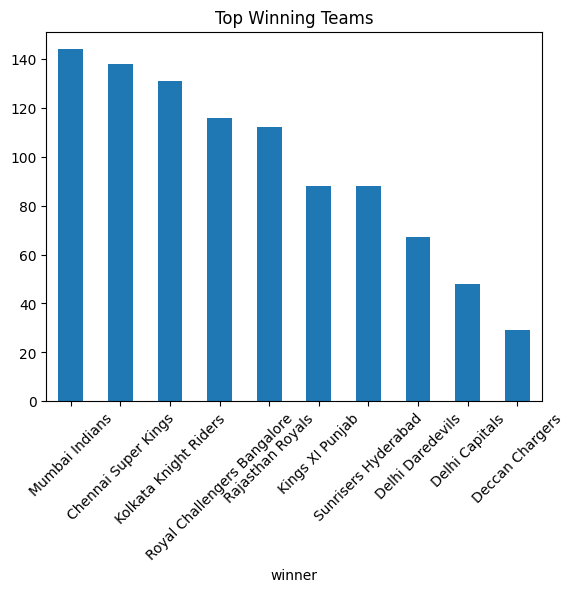

In [ ]:
# number of wins
wins = df_matches['winner'].value_counts().head(10)

wins.plot(kind='bar')
plt.title("Top Winning Teams")
plt.xticks(rotation=45)
plt.show()

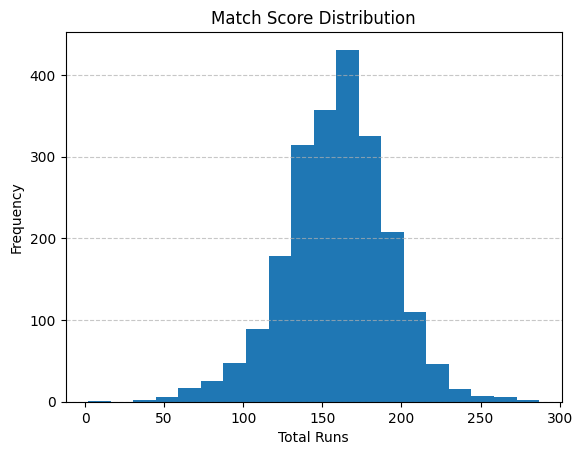

In [ ]:
# match score distribution
plt.hist(runs_per_team_per_match['total_runs'], bins=20)
plt.title("Match Score Distribution")
plt.xlabel("Total Runs")
plt.ylabel("Frequency")
plt.grid(axis='y',linestyle='--', alpha=0.7)
plt.show()

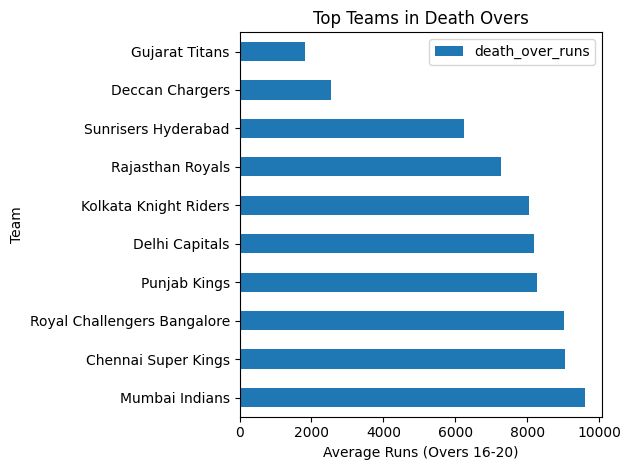

In [ ]:
# runs in death overs
top_death_over_teams.head(10).plot(
    kind='barh',
    x='batting_team',
    y='death_over_runs'
)

plt.title("Top Teams in Death Overs")
plt.xlabel("Average Runs (Overs 16-20)")
plt.ylabel("Team")

plt.tight_layout()
plt.show()

Index(['batter', 'strike_rate', 'total_runs'], dtype='str')


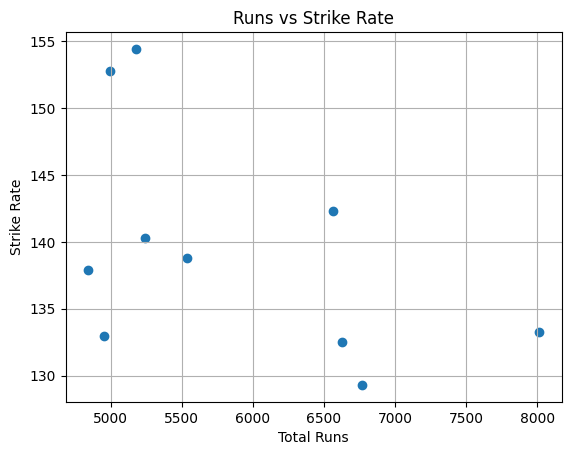

In [ ]:
# merging strike rate and top batters
strike_run = strike_rate.merge(top_batters, on='batter')

# strike rate vs total runs
plt.scatter(strike_run['total_runs'], strike_run['strike_rate'])
plt.xlabel("Total Runs")
plt.ylabel("Strike Rate")
plt.title("Runs vs Strike Rate")
plt.grid()
plt.show()